In [1]:
from google.colab import files
uploaded = files.upload()

Saving tn_population.csv to tn_population.csv


In [2]:
import pandas as pd

df = pd.read_csv("tn_population.csv")
df.head()

,Name,Status,District,1991,2001,2011
0,Chennai,Corporation,Chennai,3841396,4343645,4681087
1,Coimbatore,Corporation,Coimbatore,816321,930882,1050721
2,Madurai,Corporation,Madurai,922913,928869,1017865
3,Tiruchirappalli,Corporation,Tiruchirappalli,752066,847387,916857
4,Salem,Corporation,Salem,693236,751438,829267


In [3]:
!pip install folium geopy seaborn


**Geographical Point Map**
   (where cities are located)

In [8]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="colab-tn-population-mapper", timeout=10)

def get_coordinates(city_name):
    try:
        location = geolocator.geocode(city_name + ", Tamil Nadu, India")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except Exception as e:
        print(f"Error geocoding {city_name}: {e}")
        return None, None
    finally:
        time.sleep(1) # Add a small delay to respect Nominatim usage policy

df[['Latitude', 'Longitude']] = df['Name'].apply(lambda x: pd.Series(get_coordinates(x)))

import folium

map_tn = folium.Map(location=[11.0, 78.0], zoom_start=7, tiles="CartoDB positron")

for i in range(len(df)):
    # Only add marker if coordinates are available
    if pd.notna(df.loc[i, "Latitude"]) and pd.notna(df.loc[i, "Longitude"]):
        folium.CircleMarker(
            location=[df.loc[i, "Latitude"], df.loc[i, "Longitude"]],
            radius=6,
            popup=f"{df.loc[i,'Name']} ({df.loc[i,'2011']})",
            color="#2E86C1",
            fill=True,
            fill_color="#2E86C1"
        ).add_to(map_tn)

map_tn

**Heat Map**
(population density)

In [9]:
from folium.plugins import HeatMap

heat_data = [[row['Latitude'], row['Longitude'], row['2011']] for index, row in df.iterrows()]

map_heat = folium.Map(location=[11.0, 78.0], zoom_start=7, tiles="CartoDB dark_matter")

HeatMap(heat_data, radius=15).add_to(map_heat)

map_heat

**Bubble Map**
(population size visually)

In [2]:
map_bubble = folium.Map(location=[11.0, 78.0], zoom_start=7, tiles="CartoDB positron")

for i in range(len(df)):
    folium.Circle(
            location=[df.loc[i, "Latitude"], df.loc[i, "Longitude"]],
                    radius=df.loc[i, "2011"] / 50,
                            color="#E74C3C",
                                    fill=True,
                                            fill_color="#E74C3C",
                                                    fill_opacity=0.5,
                                                            popup=df.loc[i, "Name"]
                                                                ).add_to(map_bubble)

map_bubble

NameError: name 'folium' is not defined

**Line Graph**
((Population Growth))

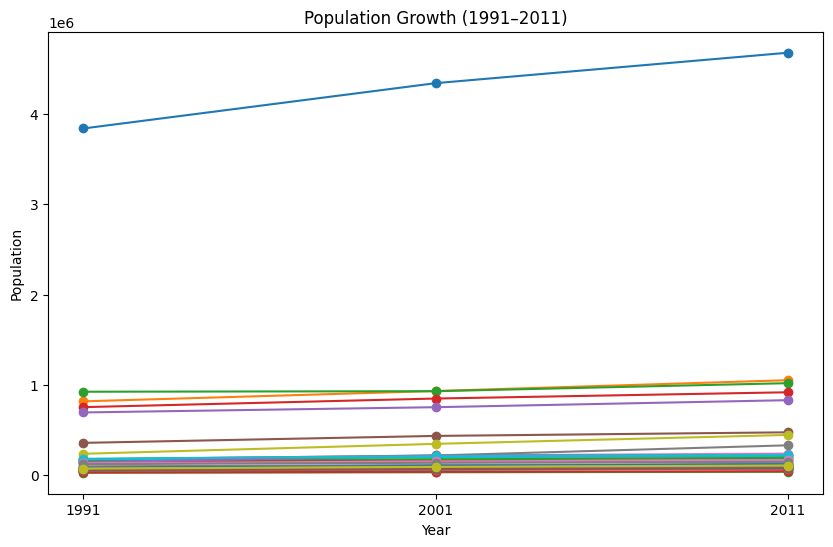

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i in range(len(df)):
    plt.plot(
            ["1991","2001","2011"],
                    [df.loc[i,"1991"], df.loc[i,"2001"], df.loc[i,"2011"]],
                            marker='o'
                                )

plt.title("Population Growth (1991–2011)")
plt.xlabel("Year")
plt.ylabel("Population")

plt.show()